In [3]:
using Pkg


using SolidStateDetectors
using Unitful
using Plots
using LegendHDF5IO

# 0.3 mm max tick

In [28]:
refinement = [
    "None",
    0.2,
    0.1,
    0.05,
    0.02,
    0.01,
    0.005,
    0.0035,
    0.002
]

min_ϕ_03 = [
    0.90511775,
    0.90511775,
    0.915471,
    0.9170997,
    0.91737044,
    0.9173459,
    0.91738874,
    0.9173889,
    0.91738683
]
min_ϕ_05 = [
    0.990916,     # senza refinement
    0.990916,     # refinement 0.2
    0.99268365,   # refinement 0.1
    0.9926757,    # refinement 0.05
    0.9926764,    # refinement 0.02
    0.9926772,    # refinement 0.01
    0.99268293,   # refinement 0.005
    0.99268544,   # refinement 0.0035
    0.9926831     # refinement 0.002
]


abs_diff_03 = 1 .-min_ϕ_03 
abs_diff_05 = 1 .-min_ϕ_05

9-element Vector{Float64}:
 0.009083999999999981
 0.009083999999999981
 0.0073163499999999715
 0.00732429999999995
 0.007323599999999986
 0.007322799999999963
 0.007317070000000037
 0.00731455999999997
 0.0073168999999999595

In [16]:
grp_03  = [
    49248,     # senza refinement
    49248,     # refinement 0.2
    50224,     # 146 * 344
    60816,     # 168 * 362
    188160,    # 336 * 560
    647460,    # 654 * 990
    2386432,   # 1264 * 1888
    5330660,   # 1930 * 2762
    7997548    # 2158 * 3706
];

grp_05 =   [
    20352,    # 96 × 212  (senza refinement)
    20352,    # 96 × 212  (refinement 0.2)
    22236,    # 102 × 218
    48720,    # 174 × 280
    178880,   # 344 × 520
    702328,   # 694 × 1012
    2667984,  # 1364 × 1956
    5756608,  # 1924 × 2992
    9237736   # 2188 × 4222
];


In [13]:
length(grp_05)

8

In [14]:
length(grp_03)

9

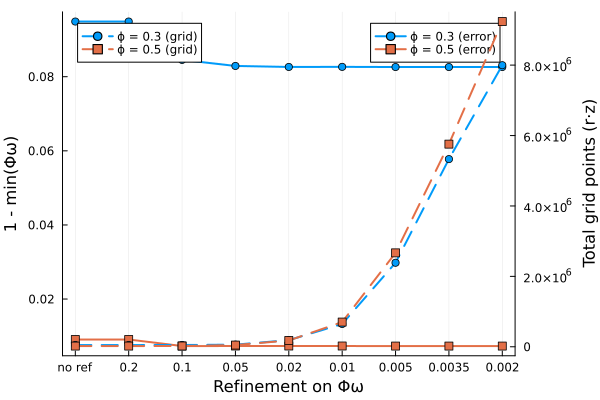

In [21]:
using Plots

labels = ["no ref", "0.2", "0.1", "0.05", "0.02", "0.01", "0.005", "0.0035", "0.002"]
x = 1:length(labels)

# --- asse sinistro (errori) ---
p = plot(
    x, abs_diff_03,
    xticks = (x, labels),
    xlabel = "Refinement on Φω",
    ylabel = "1 - min(Φω)",
    linewidth = 2,
    marker = :circle,
    label = "ϕ = 0.3 (error)"
)

plot!(
    x, abs_diff_05,
    linewidth = 2,
    marker = :square,
    label = "ϕ = 0.5 (error)"
)

# --- crea UNA VOLTA sola l'asse destro ---
p_right = twinx()

plot!(
    p_right,
    x, grp_03,
    ylabel = "Total grid points (r·z)",
    linewidth = 2,
    linestyle = :dash,
    marker = :circle,
    label = "ϕ = 0.3 (grid)"
)

plot!(
    p_right,
    x, grp_05,
    linewidth = 2,
    linestyle = :dash,
    marker = :square,
    label = "ϕ = 0.5 (grid)"
)

display(p)


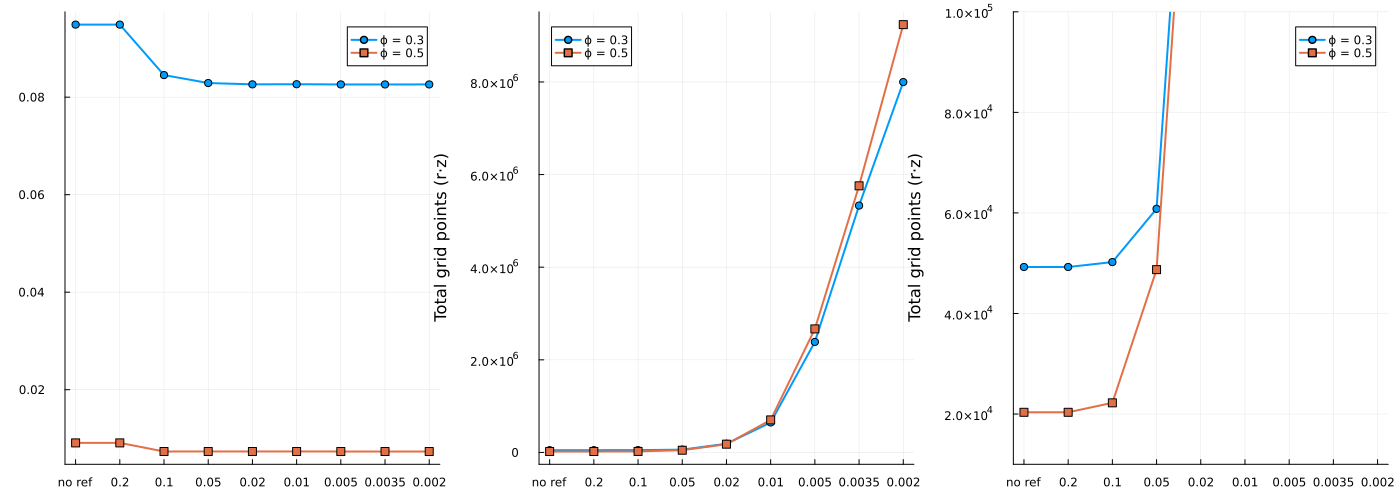

In [38]:
p_err = plot(
    x, abs_diff_03,
    xticks = (x, labels),
    xlabel = "Refinement on Φω",
    ylabel = "1 - min(Φω)",
    linewidth = 2,
    marker = :circle,
    label = "ϕ = 0.3"
)

plot!(
    x, abs_diff_05,
    linewidth = 2,
    marker = :square,
    label = "ϕ = 0.5"
)


p_grid = plot(
    x, grp_03,
    xticks = (x, labels),
    xlabel = "Refinement on Φω",
    ylabel = "Total grid points (r·z)",
    linewidth = 2,
    marker = :circle,
    label = "ϕ = 0.3"
)

plot!(
    x, grp_05,
    linewidth = 2,
    marker = :square,
    label = "ϕ = 0.5"
)

p_zoom = plot(
    x, grp_03,
    xticks = (x, labels),
    xlabel = "Refinement on Φω",
    ylabel = "Total grid points (r·z)",
    linewidth = 2,
    marker = :circle,
    label = "ϕ = 0.3"
)

plot!(
    x, grp_05,
    linewidth = 2,
    marker = :square,
    label = "ϕ = 0.5"
)

ylims!(10000, 100000)

#ylims!(1000, 100000)
plot(p_err, p_grid, p_zoom, layout = (1, 3), size = (1400, 500))
